# Analysing decomposed terms
1. raw q X raw v;
2. clim q X clim v;
3. clim q X anom v;
4. anom q X clim v;
5. anom q X anom v

# Dominance classification maps

## 1. Highest contribution maps

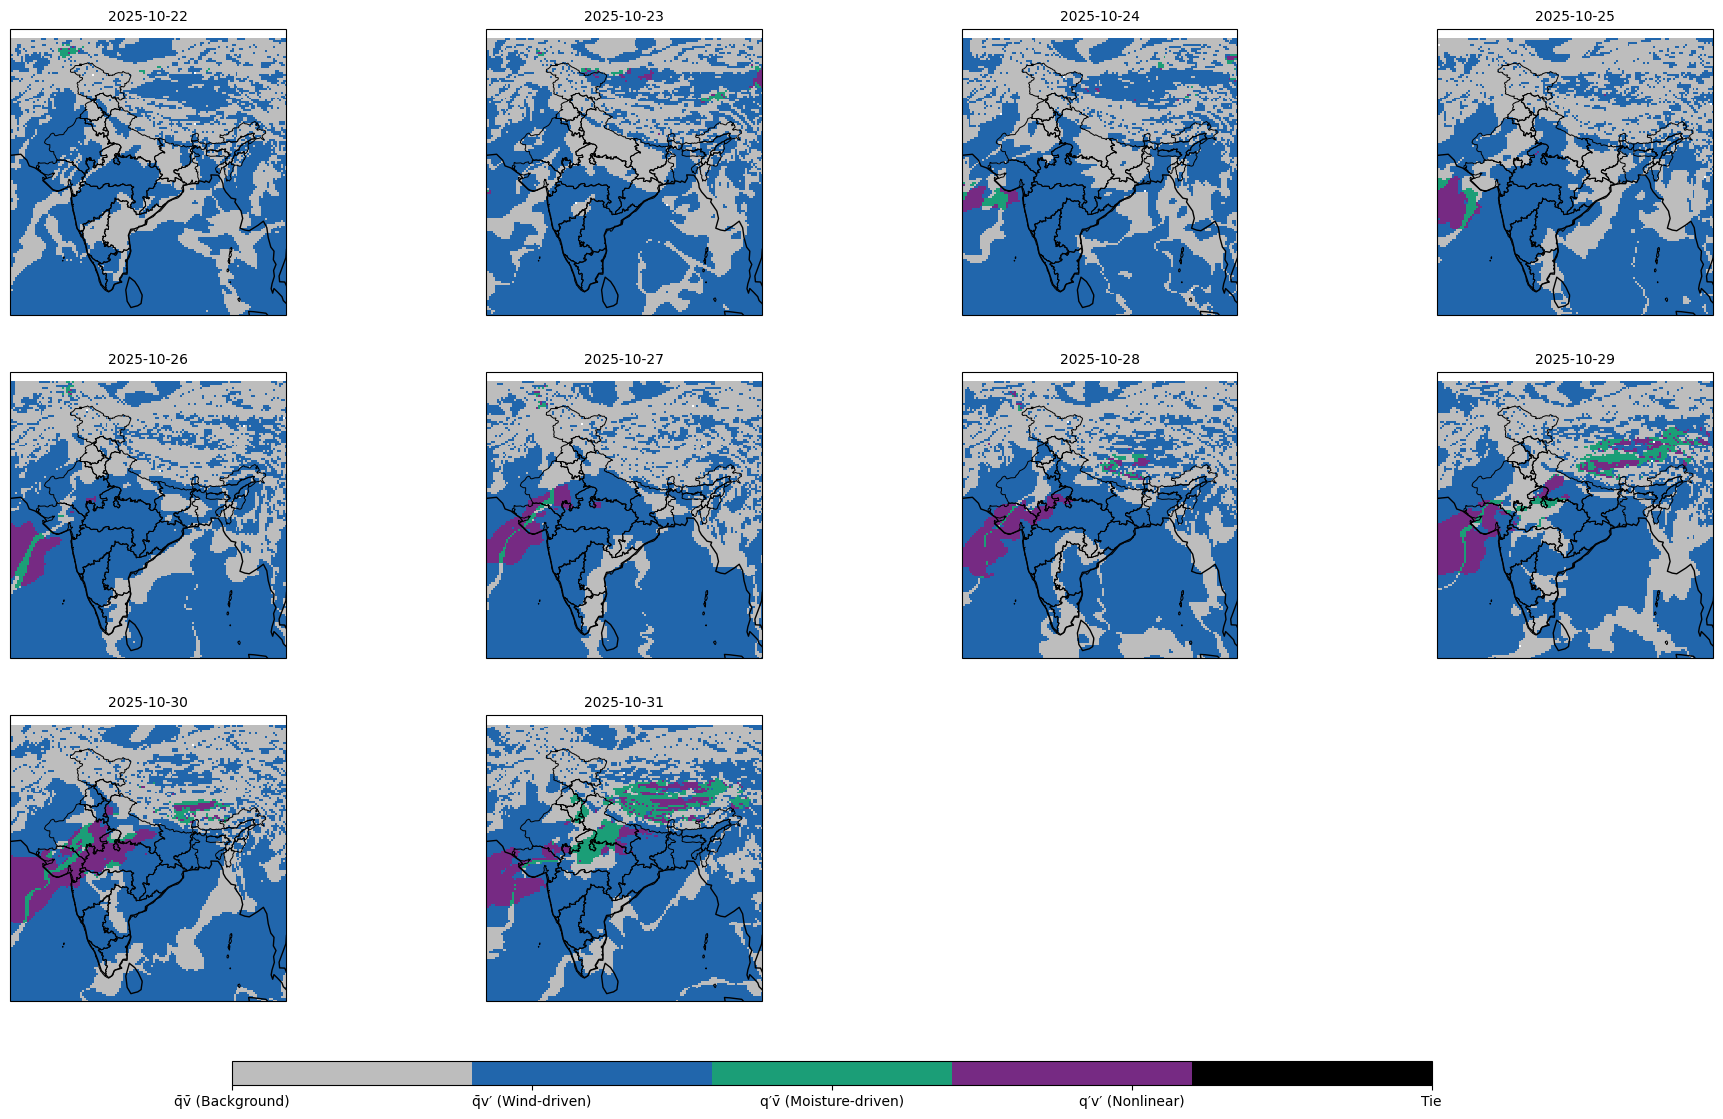

In [9]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import geopandas as gpd
import math
from matplotlib.colors import ListedColormap

# ============================
# 🔹 USER INPUT
# ============================

start_date = "2025-10-22"
end_date   = "2025-10-31"

india_shapefile = r"D:\PHD 2025~\PHD\Shapefiles\India Shapefile With Kashmir\india_st.shp"

# Optional masking threshold
threshold = 1e-6

# ============================
# 🔹 LOAD DATA
# ============================

qv = xr.open_dataarray(r"D:\PHD 2025~\1.SERVER_1\Moisture_no_tp_files\decomposted terms\qv_850.nc")

qbar_vbar   = xr.open_dataarray(r"D:\PHD 2025~\1.SERVER_1\Moisture_no_tp_files\decomposted terms\qbar_vbar_850.nc")
qbar_vprime = xr.open_dataarray(r"D:\PHD 2025~\1.SERVER_1\Moisture_no_tp_files\decomposted terms\qbar_vprime_850.nc")
qprime_vbar = xr.open_dataarray(r"D:\PHD 2025~\1.SERVER_1\Moisture_no_tp_files\decomposted terms\qprime_vbar_850.nc")

ds = xr.open_dataset(r"D:\PHD 2025~\1.SERVER_1\Moisture_no_tp_files\decomposted terms\v_q_850.nc")
qprime_vprime = ds['vq']

if 'time' in qprime_vprime.dims:
    qprime_vprime = qprime_vprime.rename({'time': 'valid_time'})

qprime_vprime = qprime_vprime.expand_dims({'pressure_level':[850]})

qv, qbar_vbar, qbar_vprime, qprime_vbar, qprime_vprime = xr.align(
    qv, qbar_vbar, qbar_vprime, qprime_vbar, qprime_vprime
)

# ============================
# 🔹 REGION
# ============================

lat_slice = slice(40, 5)
lon_slice = slice(60, 100)

qv = qv.sel(latitude=lat_slice, longitude=lon_slice)

qbar_vbar   = qbar_vbar.sel(latitude=lat_slice, longitude=lon_slice)
qbar_vprime = qbar_vprime.sel(latitude=lat_slice, longitude=lon_slice)
qprime_vbar = qprime_vbar.sel(latitude=lat_slice, longitude=lon_slice)
qprime_vprime = qprime_vprime.sel(latitude=lat_slice, longitude=lon_slice)

# ============================
# 🔹 TIME
# ============================

qv = qv.sel(valid_time=slice(start_date, end_date))

qbar_vbar   = qbar_vbar.sel(valid_time=qv.valid_time)
qbar_vprime = qbar_vprime.sel(valid_time=qv.valid_time)
qprime_vbar = qprime_vbar.sel(valid_time=qv.valid_time)
qprime_vprime = qprime_vprime.sel(valid_time=qv.valid_time)

# ============================
# 🔹 CLASSIFICATION
# ============================

def classify_day(t):

    term1 = np.abs(qbar_vbar.isel(valid_time=t).squeeze())
    term2 = np.abs(qbar_vprime.isel(valid_time=t).squeeze())
    term3 = np.abs(qprime_vbar.isel(valid_time=t).squeeze())
    term4 = np.abs(qprime_vprime.isel(valid_time=t).squeeze())

    terms = np.stack([term1, term2, term3, term4], axis=0)

    max_val = np.max(terms, axis=0)

    tie_mask = np.sum(terms == max_val, axis=0) > 1

    dominant = np.argmax(terms, axis=0) + 1
    dominant[tie_mask] = 5

    base_flux = np.abs(qv.isel(valid_time=t).squeeze())
    dominant = np.where(base_flux < threshold, np.nan, dominant)

    return dominant

# ============================
# 🔹 SHAPEFILE
# ============================

india = gpd.read_file(india_shapefile)

# ============================
# 🔹 FIGURE SETUP
# ============================

times = qv.valid_time.values
n_days = len(times)

ncols = 4
nrows = math.ceil(n_days / ncols)

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(5*ncols, 4*nrows),  # bigger panels
    subplot_kw={'projection': ccrs.PlateCarree()}
)

axes = axes.flatten()

# ============================
# 🔹 NEW COLORS
# ============================

colors = ["#bdbdbd", "#2166ac", "#1b9e77", "#762a83", "#000000"]
cmap = ListedColormap(colors)

# ============================
# 🔹 PLOTTING
# ============================

for i, t in enumerate(times):

    ax = axes[i]

    cls = classify_day(i)

    im = ax.pcolormesh(
        qv.longitude,
        qv.latitude,
        cls,
        cmap=cmap,
        vmin=1,
        vmax=5,
        transform=ccrs.PlateCarree(),
        shading='auto'
    )

    india.boundary.plot(ax=ax, edgecolor='black', linewidth=0.7)
    ax.coastlines(resolution='110m')

    ax.set_extent([65, 100, 5, 40])
    ax.set_aspect('equal', adjustable='box')

    ax.set_title(str(np.datetime_as_string(t, unit='D')), fontsize=10)

# remove extra axes
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

# ============================
# 🔹 COLORBAR (FIXED POSITION)
# ============================

cbar_ax = fig.add_axes([0.2, 0.05, 0.6, 0.02])

cbar = fig.colorbar(im, cax=cbar_ax, orientation='horizontal')

cbar.set_ticks([1,2,3,4,5])
cbar.set_ticklabels([
    'q̄v̄ (Background)',
    'q̄v′ (Wind-driven)',
    'q′v̄ (Moisture-driven)',
    'q′v′ (Nonlinear)',
    'Tie'
])

# ============================
# 🔹 SPACING CONTROL
# ============================

plt.subplots_adjust(
    left=0.05,
    right=0.98,
    top=0.93,
    bottom=0.12,
    wspace=0.1,
    hspace=0.2
)

plt.show()

## 2. >=50% contribution map

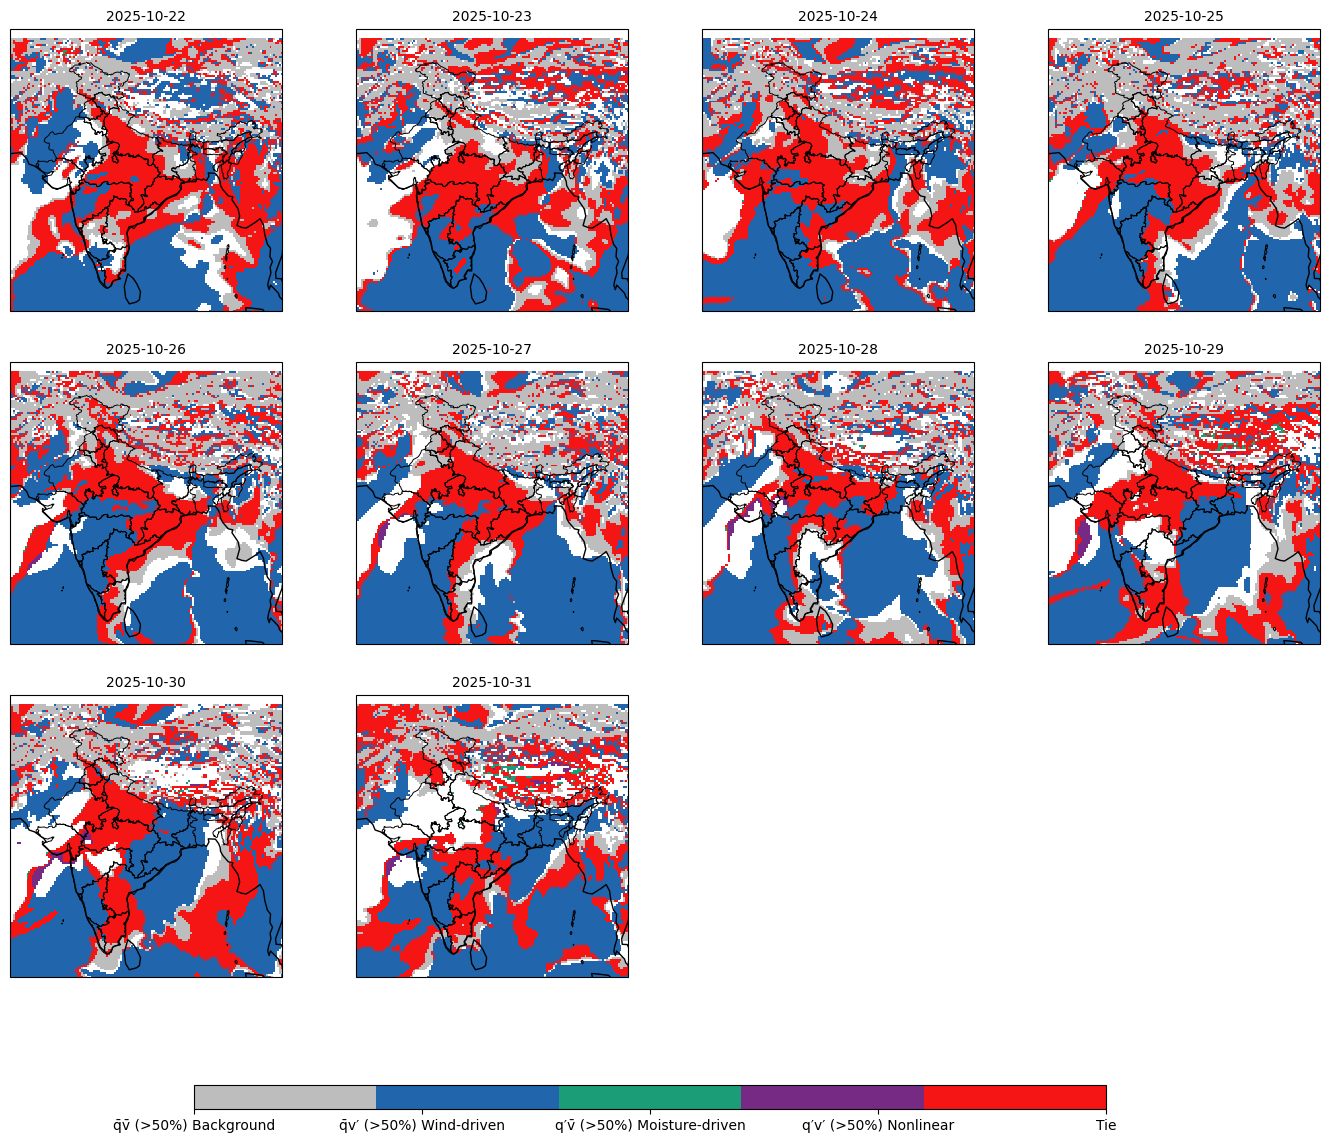

In [15]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import geopandas as gpd
import math
from matplotlib.colors import ListedColormap

# ============================
# 🔹 USER INPUT
# ============================

start_date = "2025-10-22"
end_date   = "2025-10-31"

threshold_percent = 60
threshold = threshold_percent / 100

india_shapefile = r"D:\PHD 2025~\PHD\Shapefiles\India Shapefile With Kashmir\india_st.shp"

# ============================
# 🔹 LOAD DATA
# ============================

qv = xr.open_dataarray(r"D:\PHD 2025~\1.SERVER_1\Moisture_no_tp_files\decomposted terms\qv_850.nc")

qbar_vbar   = xr.open_dataarray(r"D:\PHD 2025~\1.SERVER_1\Moisture_no_tp_files\decomposted terms\qbar_vbar_850.nc")
qbar_vprime = xr.open_dataarray(r"D:\PHD 2025~\1.SERVER_1\Moisture_no_tp_files\decomposted terms\qbar_vprime_850.nc")
qprime_vbar = xr.open_dataarray(r"D:\PHD 2025~\1.SERVER_1\Moisture_no_tp_files\decomposted terms\qprime_vbar_850.nc")

ds = xr.open_dataset(r"D:\PHD 2025~\1.SERVER_1\Moisture_no_tp_files\decomposted terms\v_q_850.nc")
qprime_vprime = ds['vq']

# Fix time dimension
if 'time' in qprime_vprime.dims:
    qprime_vprime = qprime_vprime.rename({'time': 'valid_time'})

# Add pressure dimension
qprime_vprime = qprime_vprime.expand_dims({'pressure_level':[850]})

# Align all datasets
qv, qbar_vbar, qbar_vprime, qprime_vbar, qprime_vprime = xr.align(
    qv, qbar_vbar, qbar_vprime, qprime_vbar, qprime_vprime
)

# ============================
# 🔹 REGION
# ============================

lat_slice = slice(40, 5)
lon_slice = slice(60, 100)

qv = qv.sel(latitude=lat_slice, longitude=lon_slice)

qbar_vbar   = qbar_vbar.sel(latitude=lat_slice, longitude=lon_slice)
qbar_vprime = qbar_vprime.sel(latitude=lat_slice, longitude=lon_slice)
qprime_vbar = qprime_vbar.sel(latitude=lat_slice, longitude=lon_slice)
qprime_vprime = qprime_vprime.sel(latitude=lat_slice, longitude=lon_slice)

# ============================
# 🔹 TIME
# ============================

qv = qv.sel(valid_time=slice(start_date, end_date))

qbar_vbar   = qbar_vbar.sel(valid_time=qv.valid_time)
qbar_vprime = qbar_vprime.sel(valid_time=qv.valid_time)
qprime_vbar = qprime_vbar.sel(valid_time=qv.valid_time)
qprime_vprime = qprime_vprime.sel(valid_time=qv.valid_time)

# ============================
# 🔹 CLASSIFICATION FUNCTION (FIXED)
# ============================

def classify_day(t):

    term1 = np.abs(qbar_vbar.isel(valid_time=t).squeeze())
    term2 = np.abs(qbar_vprime.isel(valid_time=t).squeeze())
    term3 = np.abs(qprime_vbar.isel(valid_time=t).squeeze())
    term4 = np.abs(qprime_vprime.isel(valid_time=t).squeeze())

    total = np.abs(qv.isel(valid_time=t).squeeze())

    # avoid division by zero
    total = xr.where(total < 1e-10, np.nan, total)

    c1 = term1 / total
    c2 = term2 / total
    c3 = term3 / total
    c4 = term4 / total

    # stack safely using xarray
    contributions = xr.concat([c1, c2, c3, c4], dim="term")

    mask = contributions > threshold
    count = mask.sum(dim="term")

    dominant = contributions.argmax(dim="term") + 1
    dominant = dominant.astype(float)

    # apply classification rules
    dominant = dominant.where(count != 0)     # no dominant → NaN
    dominant = dominant.where(count <= 1, 5)  # tie → class 5

    return dominant

# ============================
# 🔹 SHAPEFILE
# ============================

india = gpd.read_file(india_shapefile)

# ============================
# 🔹 FIGURE SETUP
# ============================

times = qv.valid_time.values
n_days = len(times)

ncols = 4
nrows = math.ceil(n_days / ncols)

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(3.8*ncols, 4*nrows),
    subplot_kw={'projection': ccrs.PlateCarree()}
)

axes = axes.flatten()

# ============================
# 🔹 COLORS
# ============================

colors = ["#bdbdbd", "#2166ac", "#1b9e77", "#762a83", "#F51515"]
cmap = ListedColormap(colors)

# ============================
# 🔹 PLOTTING
# ============================

for i, t in enumerate(times):

    ax = axes[i]

    cls = classify_day(i)

    im = ax.pcolormesh(
        qv.longitude,
        qv.latitude,
        cls,
        cmap=cmap,
        vmin=1,
        vmax=5,
        transform=ccrs.PlateCarree(),
        shading='auto'
    )

    india.boundary.plot(ax=ax, edgecolor='black', linewidth=0.7)
    ax.coastlines(resolution='110m')

    ax.set_extent([65, 100, 5, 40])
    ax.set_aspect('equal', adjustable='box')

    ax.set_title(str(np.datetime_as_string(t, unit='D')), fontsize=10)

# remove extra axes
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

# ============================
# 🔹 COLORBAR
# ============================

cbar_ax = fig.add_axes([0.2, 0.03, 0.6, 0.02])

cbar = fig.colorbar(im, cax=cbar_ax, orientation='horizontal')

cbar.set_ticks([1,2,3,4,5])
cbar.set_ticklabels([
    'q̄v̄ (>50%) Background',
    'q̄v′ (>50%) Wind-driven',
    'q′v̄ (>50%) Moisture-driven',
    'q′v′ (>50%) Nonlinear',
    'Tie'
])

# ============================
# 🔹 SPACING
# ============================

plt.subplots_adjust(
    left=0.06,
    right=0.96,
    top=0.93,
    bottom=0.14,
    wspace=0.05,
    hspace=0.18
)

plt.show()

## 3. plotting 4 properties side by side

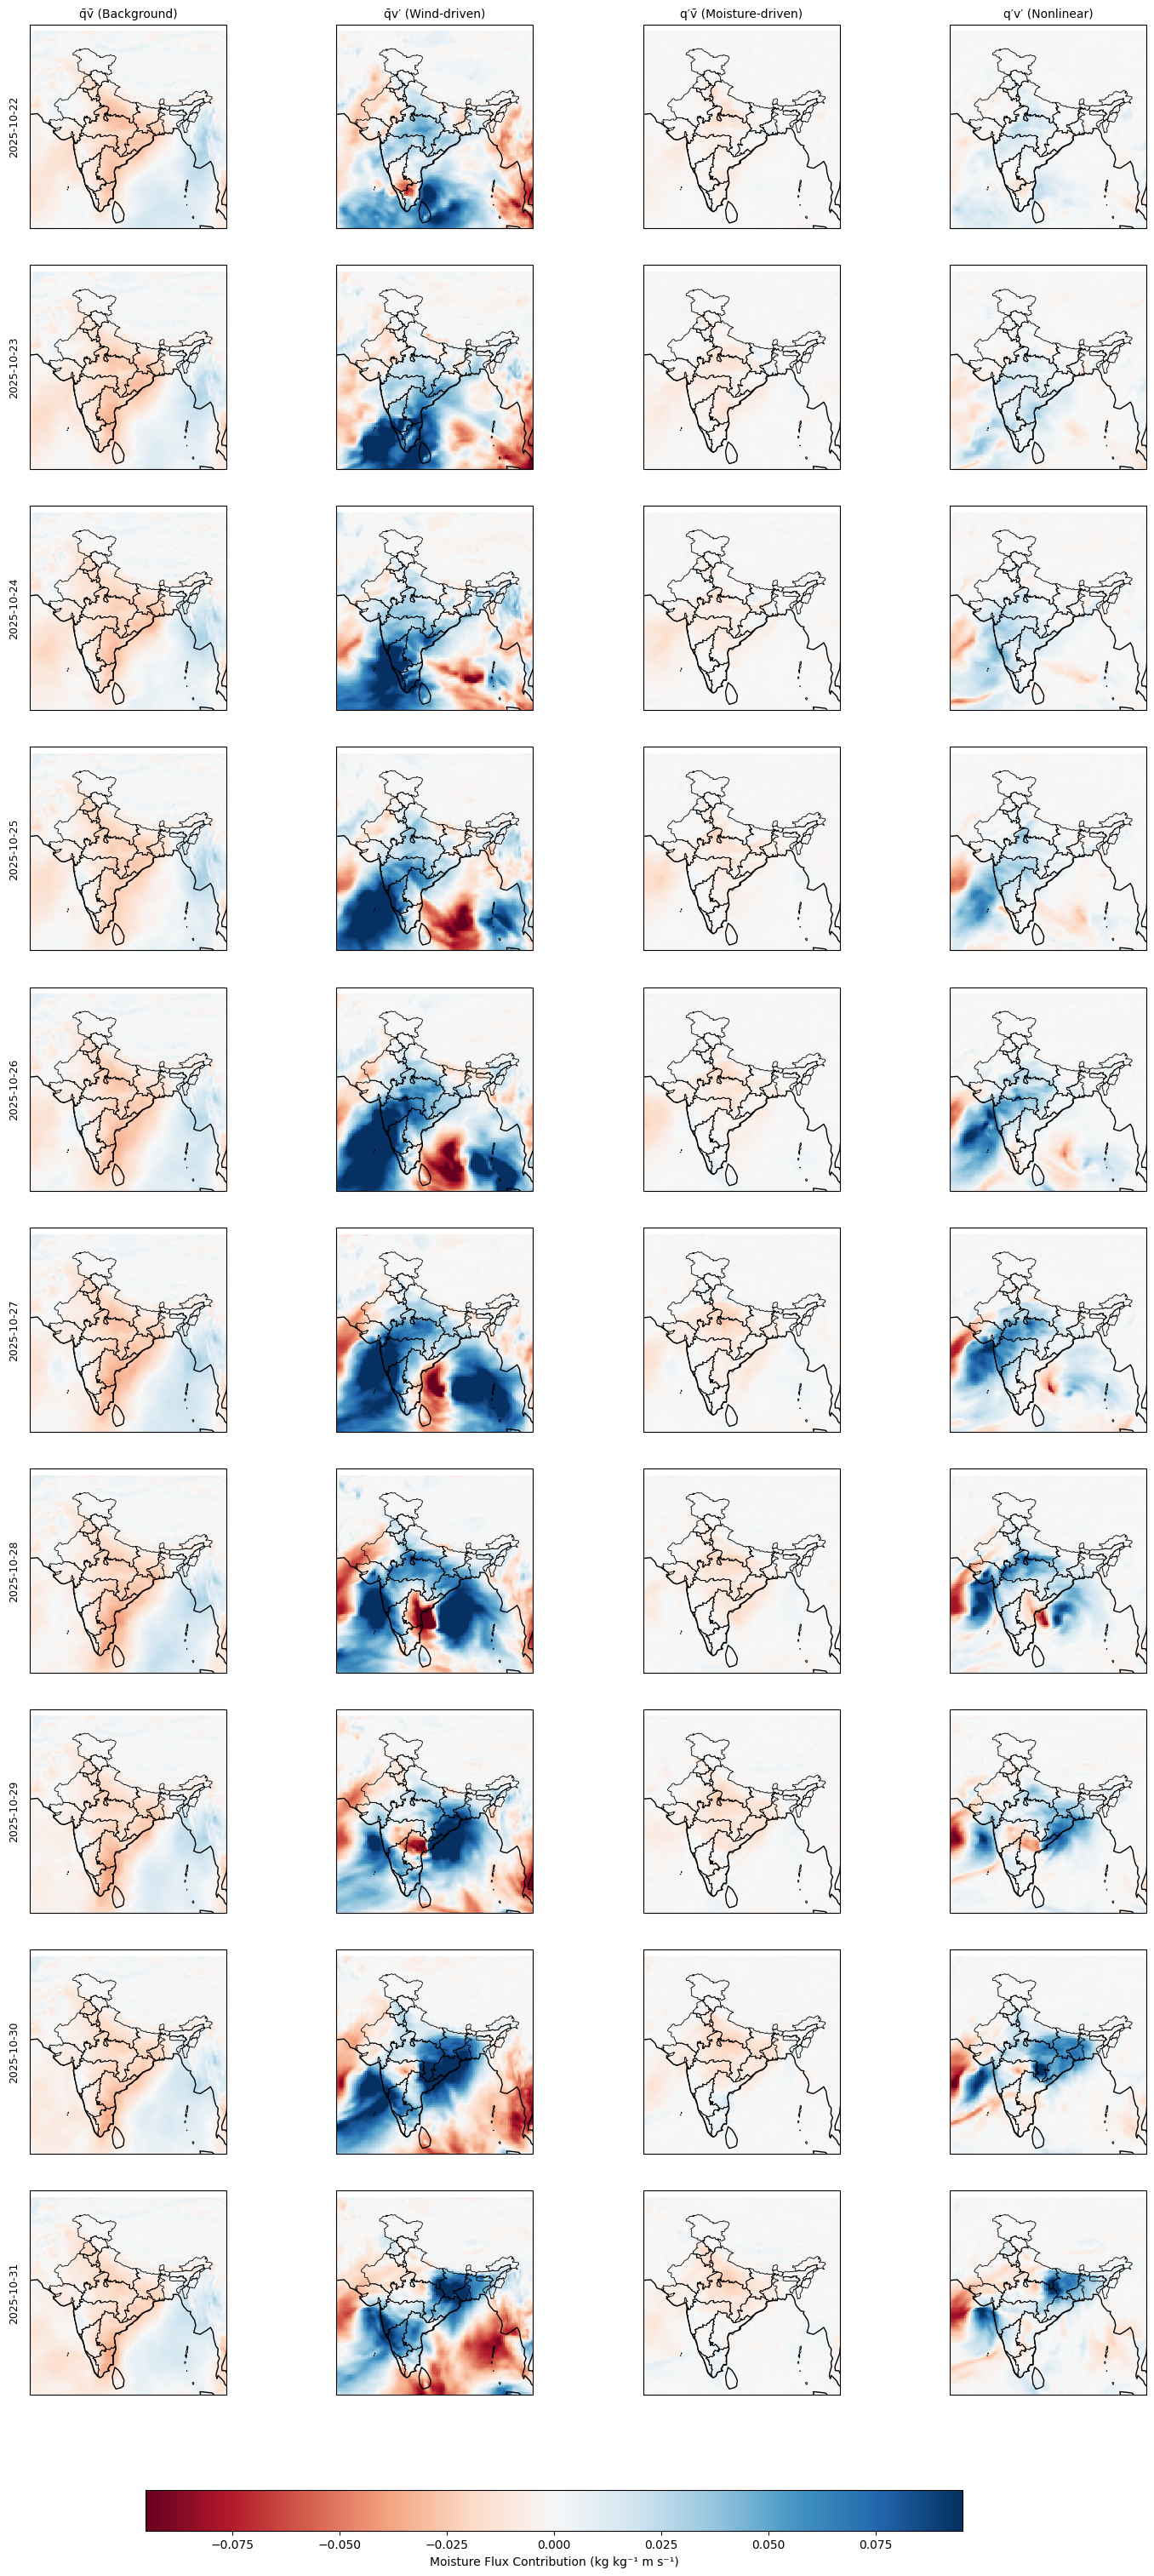

In [18]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import geopandas as gpd
import math

# ============================
# 🔹 USER INPUT
# ============================

start_date = "2025-10-22"
end_date   = "2025-10-31"

india_shapefile = r"D:\PHD 2025~\PHD\Shapefiles\India Shapefile With Kashmir\india_st.shp"

# Optional: mask very weak values
threshold = 1e-8

# ============================
# 🔹 LOAD DATA
# ============================

qbar_vbar   = xr.open_dataarray(r"D:\PHD 2025~\1.SERVER_1\Moisture_no_tp_files\decomposted terms\qbar_vbar_850.nc")
qbar_vprime = xr.open_dataarray(r"D:\PHD 2025~\1.SERVER_1\Moisture_no_tp_files\decomposted terms\qbar_vprime_850.nc")
qprime_vbar = xr.open_dataarray(r"D:\PHD 2025~\1.SERVER_1\Moisture_no_tp_files\decomposted terms\qprime_vbar_850.nc")

ds = xr.open_dataset(r"D:\PHD 2025~\1.SERVER_1\Moisture_no_tp_files\decomposted terms\v_q_850.nc")
qprime_vprime = ds['vq']

# Fix time naming
if 'time' in qprime_vprime.dims:
    qprime_vprime = qprime_vprime.rename({'time': 'valid_time'})

# Add pressure dimension
qprime_vprime = qprime_vprime.expand_dims({'pressure_level':[850]})

# Align all
qbar_vbar, qbar_vprime, qprime_vbar, qprime_vprime = xr.align(
    qbar_vbar, qbar_vprime, qprime_vbar, qprime_vprime
)

# ============================
# 🔹 REGION
# ============================

lat_slice = slice(40, 5)
lon_slice = slice(60, 100)

qbar_vbar   = qbar_vbar.sel(latitude=lat_slice, longitude=lon_slice)
qbar_vprime = qbar_vprime.sel(latitude=lat_slice, longitude=lon_slice)
qprime_vbar = qprime_vbar.sel(latitude=lat_slice, longitude=lon_slice)
qprime_vprime = qprime_vprime.sel(latitude=lat_slice, longitude=lon_slice)

# ============================
# 🔹 TIME (FIXED VERSION)
# ============================

# Sort all first
qbar_vbar = qbar_vbar.sortby('valid_time')
qbar_vprime = qbar_vprime.sortby('valid_time')
qprime_vbar = qprime_vbar.sortby('valid_time')
qprime_vprime = qprime_vprime.sortby('valid_time')

# Select time from one reference dataset
qbar_vbar = qbar_vbar.sel(valid_time=slice(start_date, end_date))

# Align others to same time
qbar_vprime = qbar_vprime.sel(valid_time=qbar_vbar.valid_time)
qprime_vbar = qprime_vbar.sel(valid_time=qbar_vbar.valid_time)
qprime_vprime = qprime_vprime.sel(valid_time=qbar_vbar.valid_time)

# ============================
# 🔹 SHAPEFILE
# ============================

india = gpd.read_file(india_shapefile)

# ============================
# 🔹 GLOBAL COLOR SCALE
# ============================

# Use symmetric scale (important for flux interpretation)
all_data = xr.concat([
    qbar_vbar, qbar_vprime, qprime_vbar, qprime_vprime
], dim="term")

vmax = float(np.nanpercentile(np.abs(all_data.values), 99))
vmin = -vmax

# ============================
# 🔹 FIGURE SETUP
# ============================

ncols = 4
nrows = n_days

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(4*ncols, 3.2*nrows),
    subplot_kw={'projection': ccrs.PlateCarree()}
)

# Handle single-day case
if nrows == 1:
    axes = np.expand_dims(axes, axis=0)

# ============================
# 🔹 TITLES (COLUMN HEADERS)
# ============================

col_titles = [
    "q̄v̄ (Background)",
    "q̄v′ (Wind-driven)",
    "q′v̄ (Moisture-driven)",
    "q′v′ (Nonlinear)"
]

# ============================
# 🔹 LOOP THROUGH DAYS
# ============================

for i, t in enumerate(times):

    day_str = str(np.datetime_as_string(t, unit='D'))

    term_list = [
        qbar_vbar,
        qbar_vprime,
        qprime_vbar,
        qprime_vprime
    ]

    for j in range(4):

        ax = axes[i, j]

        data = term_list[j].isel(valid_time=i).squeeze()

        # Optional masking
        data = xr.where(np.abs(data) < threshold, np.nan, data)

        im = ax.pcolormesh(
            data.longitude,
            data.latitude,
            data,
            cmap="RdBu",
            vmin=vmin,
            vmax=vmax,
            transform=ccrs.PlateCarree(),
            shading='auto'
        )

        india.boundary.plot(ax=ax, edgecolor='black', linewidth=0.6)
        ax.coastlines(resolution='110m')

        ax.set_extent([65, 100, 5, 40])
        ax.set_aspect('equal', adjustable='box')

        # Column titles (only top row)
        if i == 0:
            ax.set_title(col_titles[j], fontsize=10, pad=6)

        # Row labels (only first column)
        if j == 0:
            ax.text(
                -0.08, 0.5, day_str,
                transform=ax.transAxes,
                rotation=90,
                va='center',
                ha='center',
                fontsize=9
            )

# ============================
# 🔹 COLORBAR (FIXED BOTTOM)
# ============================

cbar_ax = fig.add_axes([0.2, 0.03, 0.6, 0.015])

cbar = fig.colorbar(im, cax=cbar_ax, orientation='horizontal')

cbar.set_label("Moisture Flux Contribution (kg kg⁻¹ m s⁻¹)", fontsize=10)

# ============================
# 🔹 SPACING CONTROL
# ============================

plt.subplots_adjust(
    left=0.08,
    right=0.97,
    top=0.95,
    bottom=0.08,
    wspace=0.05,
    hspace=0.18
)

plt.show()